<a href="https://colab.research.google.com/github/hhb7913/DeepLearning/blob/main/Image_Classification__2ClassesSolarCellV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Image Classification** using YOLO11 and YOLO26

In [ ]:
# Check GPU
!nvidia-smi


Tue Oct  1 14:38:12 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   54C    P8              11W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [2]:
# Install the necessary libraries
!pip install ultralytics roboflow opencv-python pandas


   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 1.1/1.1 MB 15.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/38.8 MB ? eta -:--:--
   -- ------------------------------------- 2.1/38.8 MB 10.1 MB/s eta 0:00:04
   ----- ---------------------------------- 5.2/38.8 MB 12.4 MB/s eta 0:00:03
   --------- ------------------------------ 9.2/38.8 MB 14.3 MB/s eta 0:00:03
   ------------ --------------------------- 12.3/38.8 MB 14.4 MB/s eta 0:00:02
   ---------------- ----------------------- 16.3/38.8 MB 15.3 MB/s eta 0:00:02
   -------------------- ------------------- 19.9/38.8 MB 15.7 MB/s eta 0:00:02
   ----------------------- ---------------- 23.1/38.8 MB 15.5 MB/s eta 0:00:02
   --------------------------- ------------ 26.5/38.8 MB 15.8 MB/s eta 0:00:01
   -------------------------------- ------- 31.2/38.8 MB 16.4 MB/s eta 0:00:01
   ----------------------------------- ---- 34.6/38.8 MB 16.5 MB/s eta 0:00:

In [3]:
import os
import random
import shutil
from pathlib import Path
from typing import List, Tuple

# Supported image extensions (lowercase)
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".gif", ".webp"}
CLASSES = ["Healthy", "Unhealthy"]
SPLITS = ["Train", "Validate", "Test"]

def list_images(folder: Path) -> List[Path]:
    if not folder.exists(): return []
    files = [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS]
    return sorted(files)

def stratified_split(files: List[Path], train_r: float, val_r: float, test_r: float, seed: int) -> Tuple[List[Path], List[Path], List[Path]]:
    n = len(files)
    rng = random.Random(seed)
    shuffled = files[:]
    rng.shuffle(shuffled)
    n_train = int(round(train_r * n))
    n_val = int(round(val_r * n))
    train = shuffled[:n_train]
    val = shuffled[n_train:n_train + n_val]
    test = shuffled[n_train + n_val:]
    return train, val, test

def ensure_dirs(base: Path):
    for split in SPLITS:
        for cls in CLASSES:
            (base / split / cls).mkdir(parents=True, exist_ok=True)

def copy_or_move(src: Path, dst: Path, move: bool, dry_run: bool):
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dry_run:
        print(f"[DRY-RUN] {'MOVE' if move else 'COPY'}: {src} -> {dst}")
        return
    if move: shutil.move(str(src), str(dst))
    else: shutil.copy2(str(src), str(dst))

def unique_destination_path(dst: Path) -> Path:
    if not dst.exists(): return dst
    stem, suffix, parent, i = dst.stem, dst.suffix, dst.parent, 1
    while True:
        candidate = parent / f"{stem}_{i}{suffix}"
        if not candidate.exists(): return candidate
        i += 1

# --- THE SPLIT IMAGES FUNCTION ---
def SplitImageFiles(
    source_path: str, 
    dest_path: str, 
    train_ratio: float, 
    val_ratio: float, 
    test_ratio: float, 
    seed: int = 42, 
    move: bool = False, 
    dry_run: bool = False,
    case_insensitive: bool = False,
    allow_overwrite: bool = False
):
    source = Path(source_path).resolve()
    dest = Path(dest_path).resolve()

    if not (0.999 <= (train_ratio + val_ratio + test_ratio) <= 1.001):
        raise ValueError("Ratios must sum to 1.0")

    class_map = {}
    for cls in CLASSES:
        src_dir = None
        if case_insensitive:
            for child in source.iterdir() if source.exists() else []:
                if child.is_dir() and child.name.lower() == cls.lower():
                    src_dir = child
                    break
        else:
            src_dir = source / cls

        if src_dir is None or not src_dir.exists():
            print(f"Warning: Could not find folder '{cls}' in {source}")
            continue
        class_map[cls] = src_dir

    ensure_dirs(dest)
    
    for cls, cls_src in class_map.items():
        files = list_images(cls_src)
        if not files: continue

        train_f, val_f, test_f = stratified_split(files, train_ratio, val_ratio, test_ratio, seed)

        for (split_name, split_list) in [("Train", train_f), ("Validate", val_f), ("Test", test_f)]:
            for src_path in split_list:
                dst_path = dest / split_name / cls / src_path.name
                if not allow_overwrite:
                    dst_path = unique_destination_path(dst_path)
                copy_or_move(src_path, dst_path, move, dry_run)
    
    print(f"Processing complete. Files located at: {dest}")

# Example of calling the function:
if __name__ == "__main__":
    SplitImageFiles(
        source_path="./DTUSinglecelldata/ProcessedEL/SampleTwoClasses", 
        dest_path="./DTUSinglecelldata/ProcessedEL/SampleTwoClassesoutputv2",
        train_ratio=0.7,
        val_ratio=0.15,
        test_ratio=0.15
    )


Processing complete. Files located at: C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\SampleTwoClassesoutputv2


In [7]:
# Download the dataset
# !pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="sypx4MtuPMfudhWyanlZ") # Use your API key here
project = rf.workspace("rockpaperscissors-adtav").project("plants-classification-zcckg")
version = project.version(3)
dataset = version.download("folder")

# Dataset link: https://universe.roboflow.com/rockpaperscissors-adtav/plants-classification-zcckg/dataset/3#


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to plants-classification-3 in folder:: 100%|██████████| 9120/9120 [00:05<00:00, 1562.77it/s]


In [1]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.18  Python-3.13.5 torch-2.8.0+cpu CPU (13th Gen Intel Core i7-13850HX)
Setup complete  (28 CPUs, 31.6 GB RAM, 432.2/471.6 GB disk)


In [1]:
# Run inference on an image with YOLO26n
!yolo predict model=yolo26n.pt source='https://ultralytics.com/images/zidane.jpg'

Ultralytics 8.4.18  Python-3.13.5 torch-2.8.0+cpu CPU (13th Gen Intel Core i7-13850HX)
YOLO26n summary (fused): 122 layers, 2,408,932 parameters, 0 gradients, 5.4 GFLOPs

Found https://ultralytics.com/images/zidane.jpg locally at zidane.jpg
image 1/1 c:\SolarData\AnnotationData\zidane.jpg: 384x640 2 persons, 1 tie, 58.5ms
Speed: 2.0ms preprocess, 58.5ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\SolarData\AnnotationData\runs\detect\predict3
 Learn more at https://docs.ultralytics.com/modes/predict


In [4]:
# Train the YOLO11 model or YOLO26 model
from ultralytics import YOLO
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

# Path to the data.yaml file
# Below follow the two Classes datasets 
#data_path = './DTUSinglecelldata/ProcessedEL/SampleTwoClassesoutput' #two classes in here generated by python script
data_path = './DTUSinglecelldata/ProcessedEL/SampleTwoClassesoutputv2' #two classes in here generated above

# Initialize the YOLO11 model - using the nano model for speed
#model = YOLO('yolo11s-cls.pt')  # Load a pretrained YOLO11 model
model = YOLO('yolo26s-cls.pt')  # Load a pretrained YOLO26 model

# Train the model
#model.train(task='classify', mode='train', data=data_path, epochs=30, imgsz=224) # task and mode are optional parameters
#model.train(task='classify', mode='train', data=data_path, epochs=120, imgsz=224, cos_lr=True, lr0=0.01, lrf=0.01, plots=True, hsv_s=0.7, fliplr=0.5, patience=100) # more options
model.train(task='classify', mode='train', data=data_path, epochs=40, imgsz=224, cos_lr=True, lr0=0.01, lrf=0.01, plots=True, hsv_s=0.7, fliplr=0.5, patience=100) # more options

# Train using CLI (In this project all python code is used instead of CLI)
# !yolo task=classify mode=train model=yolo11n-cls.pt data=data_path epochs=10


New https://pypi.org/project/ultralytics/8.4.19 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.18  Python-3.13.5 torch-2.8.0+cpu CPU (13th Gen Intel Core i7-13850HX)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=./DTUSinglecelldata/ProcessedEL/SampleTwoClassesoutputv2, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s-cls.pt, momentum=0.937, mosaic=1.0, mul

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000216D37EA6D0>
curves: []
curves_results: []
fitness: 0.9448052048683167
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.8896104097366333, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9448052048683167}
save_dir: WindowsPath('C:/SolarData/AnnotationData/runs/classify/train40')
speed: {'preprocess': 0.0005935065007191031, 'inference': 5.973106493462631, 'loss': 5.129871394049811e-05, 'postprocess': 9.285711759683229e-05}
task: 'classify'
top1: 0.8896104097366333
top5: 1.0

In [7]:
# Export the model
# model.export(format='onnx')  # You can choose 'tflite', 'torchscript', etc.


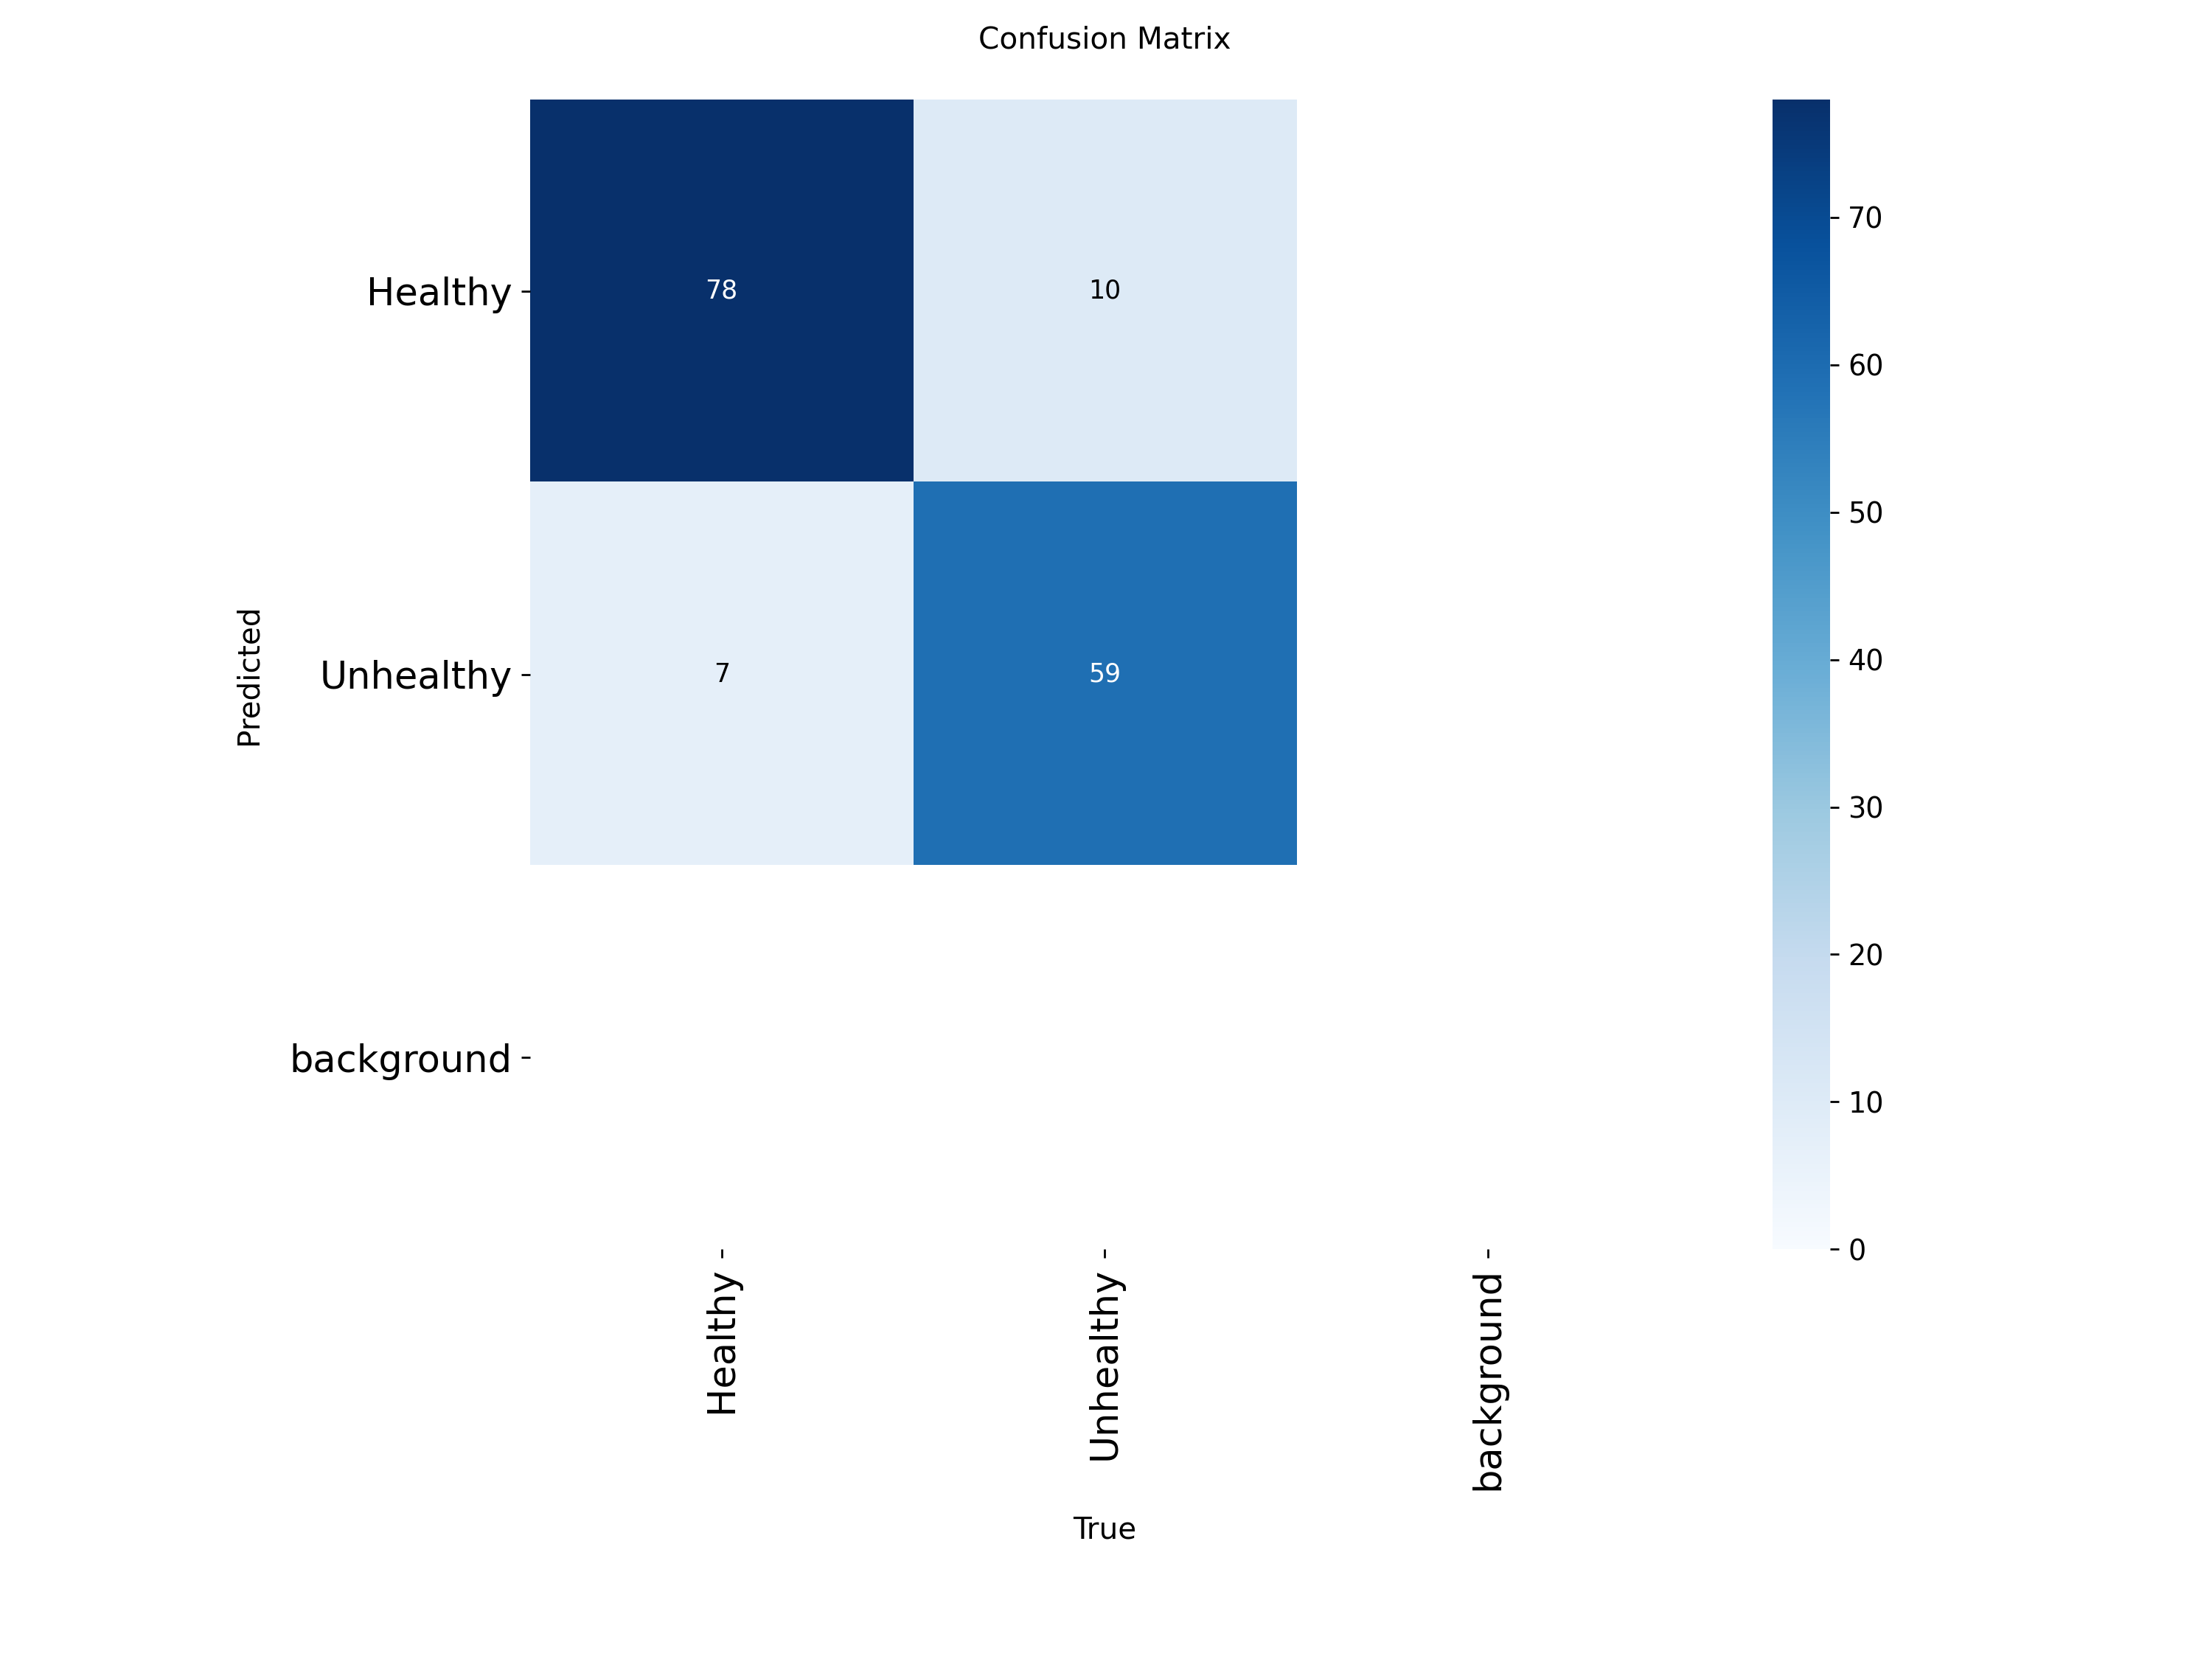

In [5]:
# Show Confusion Matrix
from IPython.display import Image, display
display(Image('./runs/classify/train40/confusion_matrix.png'))


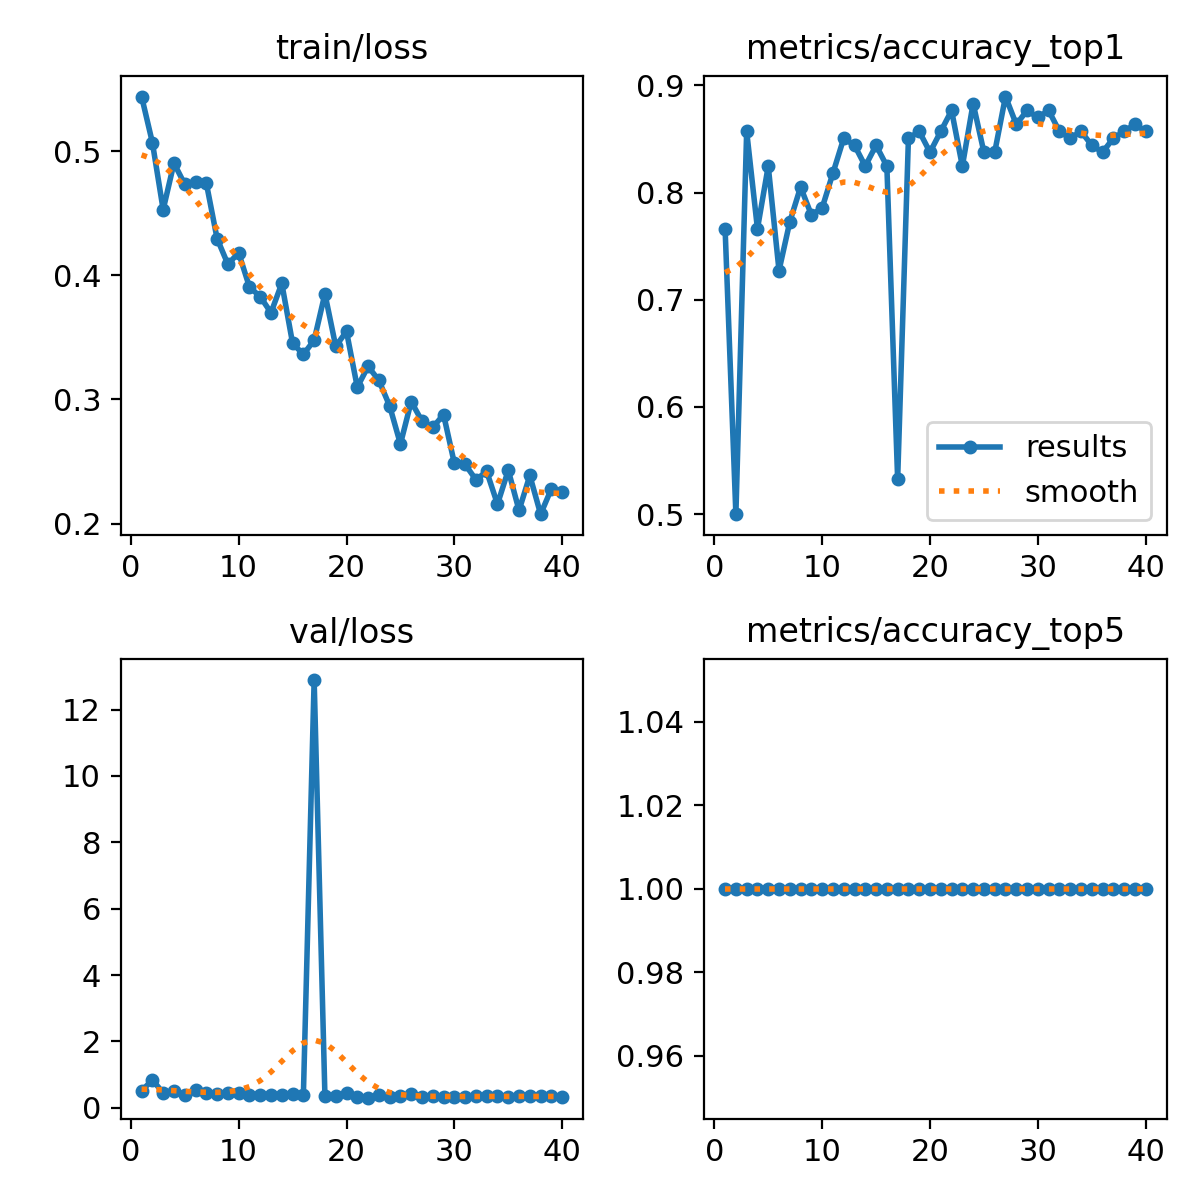

In [6]:
# Show Results (image)
display(Image('./runs/classify/train40/results.png'))


In [3]:
from ultralytics import YOLO

# 1. Load your custom trained model
model = YOLO('runs/classify/train40/weights/best.pt')

# 2. Run prediction on a new image or folder
results = model.predict(source='C:\\SolarData\\AnnotationData\\DTUSinglecelldata\\ProcessedEL\\SampleTwoClassesAllImages', save_txt=True, save=True)

# 3. Process the results (as discussed previously)
for result in results:
    #print(result.probs)  # For classification, this shows class probabilities

# Get the index of the best prediction
    top1_idx = result.probs.top1
    
    # Get the actual class name using the index
    class_name = result.names[top1_idx]
    
    # Get the confidence score
    confidence = result.probs.top1conf.item()
    
    print(f"Prediction: {class_name} ({confidence:.2f})")
    print(result.probs.top1conf)


WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1021 C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\SampleTwoClassesAllImages\13-31-~1_cell001.png: 224x224 Healthy 0.95, Unhealthy 0.05, 33.2ms
image 2/1021 C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\SampleTwoClassesAllImages\13-31-~1_cell002.png: 224x224 Healthy 0.81, Unhealthy 0.19, 47.9ms
image 3/1021 C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\SampleTwoClassesAllImages\13-31-~1_cell003.png: 224x224 Health

In [6]:
#print(result[1])
#print(results)

print(result.probs)
print(result.probs.top1conf.item())
print("the image")
print(result.orig_img[:, :, ::-1])

ultralytics.engine.results.Probs object with attributes:

data: tensor([0.0137, 0.9863])
orig_shape: None
shape: torch.Size([2])
top1: 1
top1conf: tensor(0.9863)
top5: [1, 0]
top5conf: tensor([0.9863, 0.0137])
0.9863272905349731
the image
[[[120 120 120]
  [119 119 119]
  [118 118 118]
  ...
  [113 113 113]
  [110 110 110]
  [109 109 109]]

 [[121 121 121]
  [120 120 120]
  [119 119 119]
  ...
  [114 114 114]
  [112 112 112]
  [111 111 111]]

 [[124 124 124]
  [122 122 122]
  [121 121 121]
  ...
  [117 117 117]
  [115 115 115]
  [114 114 114]]

 ...

 [[ 96  96  96]
  [ 95  95  95]
  [ 94  94  94]
  ...
  [ 97  97  97]
  [ 96  96  96]
  [ 95  95  95]]

 [[ 92  92  92]
  [ 92  92  92]
  [ 92  92  92]
  ...
  [ 93  93  93]
  [ 90  90  90]
  [ 90  90  90]]

 [[ 81  81  81]
  [ 80  80  80]
  [ 81  81  81]
  ...
  [ 87  87  87]
  [ 84  84  84]
  [ 84  84  84]]]



image 1/1021 C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\SampleTwoClassesAllImages\13-31-~1_cell001.png: 224x224 Healthy 0.95, Unhealthy 0.05, 10.7ms


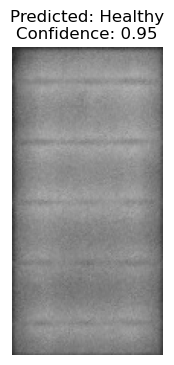

image 2/1021 C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\SampleTwoClassesAllImages\13-31-~1_cell002.png: 224x224 Healthy 0.81, Unhealthy 0.19, 15.0ms


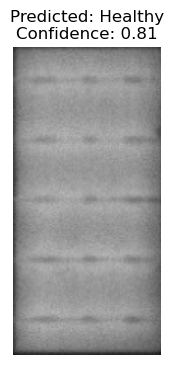

image 3/1021 C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\SampleTwoClassesAllImages\13-31-~1_cell003.png: 224x224 Healthy 0.95, Unhealthy 0.05, 19.9ms


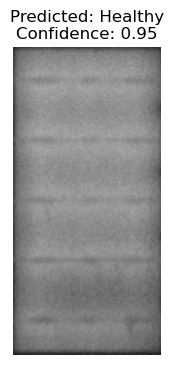

image 4/1021 C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\SampleTwoClassesAllImages\13-31-~1_cell004.png: 224x224 Healthy 0.94, Unhealthy 0.06, 18.9ms


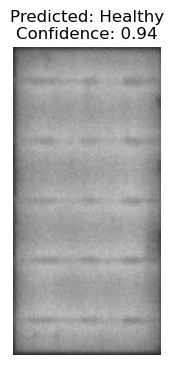

image 5/1021 C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\SampleTwoClassesAllImages\13-31-~1_cell005.png: 224x224 Healthy 0.93, Unhealthy 0.07, 12.9ms


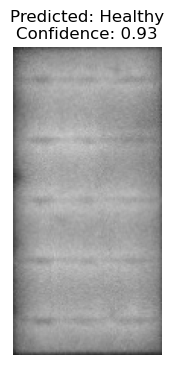

image 6/1021 C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\SampleTwoClassesAllImages\13-31-~1_cell006.png: 224x224 Healthy 0.95, Unhealthy 0.05, 15.6ms


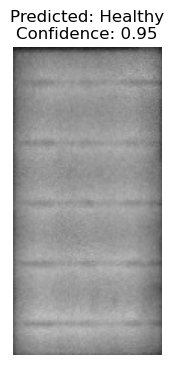

image 7/1021 C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\SampleTwoClassesAllImages\13-31-~1_cell017.png: 224x224 Healthy 0.96, Unhealthy 0.04, 15.9ms


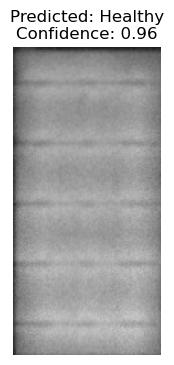

image 8/1021 C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\SampleTwoClassesAllImages\13-31-~1_cell018.png: 224x224 Healthy 0.92, Unhealthy 0.08, 16.8ms


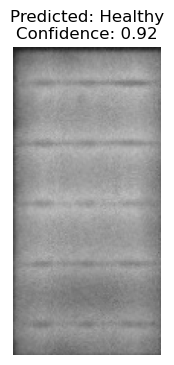

image 9/1021 C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\SampleTwoClassesAllImages\13-31-~1_cell020.png: 224x224 Healthy 0.94, Unhealthy 0.06, 11.4ms


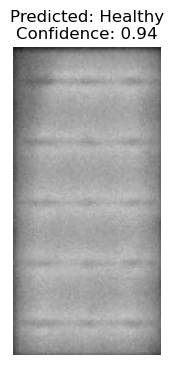

image 10/1021 C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\SampleTwoClassesAllImages\13-31-~1_cell021.png: 224x224 Healthy 0.96, Unhealthy 0.04, 15.1ms


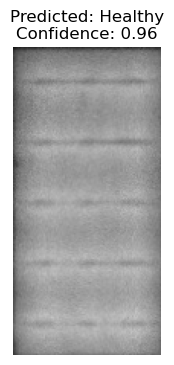

image 11/1021 C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\SampleTwoClassesAllImages\13-31-~1_cell028.png: 224x224 Unhealthy 0.95, Healthy 0.05, 18.1ms


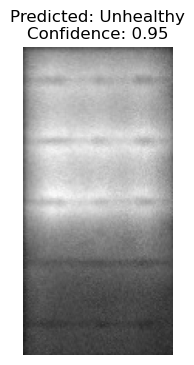

image 12/1021 C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\SampleTwoClassesAllImages\13-31-~1_cell034.png: 224x224 Unhealthy 0.94, Healthy 0.06, 15.2ms


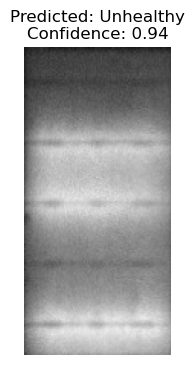

image 13/1021 C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\SampleTwoClassesAllImages\13-31-~1_cell066.png: 224x224 Unhealthy 1.00, Healthy 0.00, 13.6ms


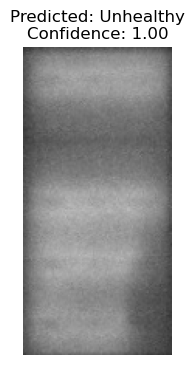

image 14/1021 C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\SampleTwoClassesAllImages\13-31-~1_cell095.png: 224x224 Healthy 0.88, Unhealthy 0.12, 16.1ms


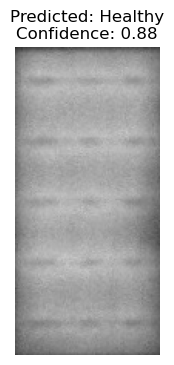

image 15/1021 C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\SampleTwoClassesAllImages\13-31-~1_cell096.png: 224x224 Healthy 0.94, Unhealthy 0.06, 15.2ms


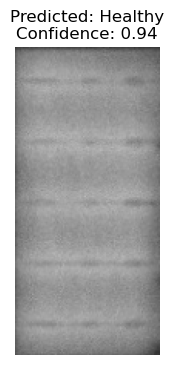

image 16/1021 C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\SampleTwoClassesAllImages\13-31-~1_cell099.png: 224x224 Healthy 0.84, Unhealthy 0.16, 41.9ms


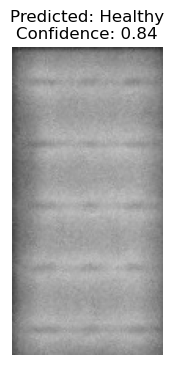

image 17/1021 C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\SampleTwoClassesAllImages\13-31-~1_cell100.png: 224x224 Healthy 0.95, Unhealthy 0.05, 17.8ms


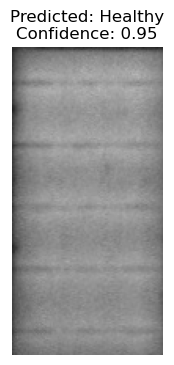

image 18/1021 C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\SampleTwoClassesAllImages\13-31-~1_cell101.png: 224x224 Healthy 0.94, Unhealthy 0.06, 19.5ms


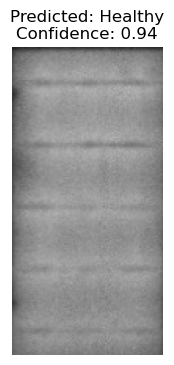

image 19/1021 C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\SampleTwoClassesAllImages\13-31-~1_cell102.png: 224x224 Healthy 0.86, Unhealthy 0.14, 19.6ms


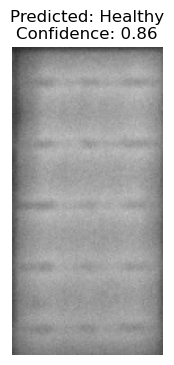

image 20/1021 C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\SampleTwoClassesAllImages\13-31-~1_cell107.png: 224x224 Healthy 0.94, Unhealthy 0.06, 21.6ms


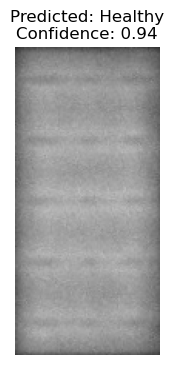

image 21/1021 C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\SampleTwoClassesAllImages\13-31-~1_cell114.png: 224x224 Unhealthy 0.58, Healthy 0.42, 21.2ms


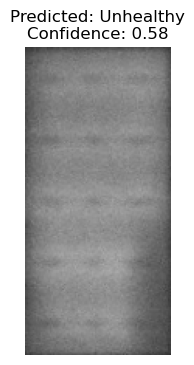

In [4]:
import matplotlib.pyplot as plt
#måske er numpy også nødvendig
import numpy as np
from ultralytics import YOLO

# 1. Load your trained model
model = YOLO('runs/classify/train40/weights/best.pt')

# 2. Run prediction on your source folder
# stream=True is efficient for large folders
results = model.predict(source='C:\\SolarData\\AnnotationData\\DTUSinglecelldata\\ProcessedEL\\SampleTwoClassesAllImages', imgsz=224, stream=True)

# 3. Loop through results and plot each image
for i, result in enumerate(results):
    # Convert BGR to RGB
    img_rgb = result.orig_img[:, :, ::-1]
    #img_rgb = result.orig_img
    
    # Extract prediction details
    top1_idx = result.probs.top1
    class_name = result.names[top1_idx]
    confidence = result.probs.top1conf.item()

    # Create plot
    plt.figure(figsize=(6, 4))
    plt.imshow(img_rgb)
    plt.title(f"Predicted: {class_name}\nConfidence: {confidence:.2f}")
    plt.axis('off')
    
    plt.show()
    
    # IMPORTANT: Close the figure to free RAM for the next loop
    plt.close() 

    # Limit for testing
    if i == 10*2: break

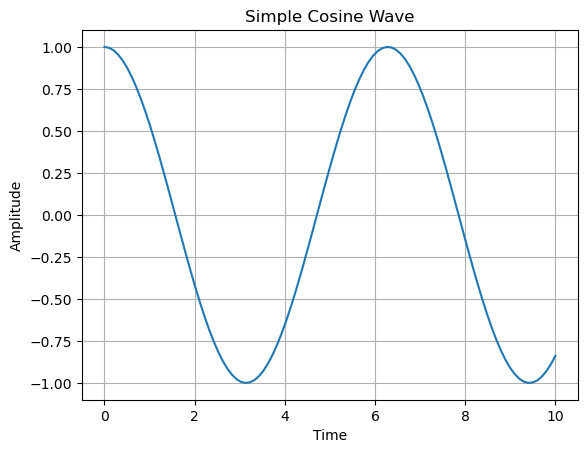

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Data
x = np.linspace(0, 10, 100)
y = np.cos(x)

# Plot
plt.plot(x, y)
plt.title("Simple Cosine Wave")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


In [5]:
metrics = model.val(data='./DTUSinglecelldata/ProcessedEL/dataset/valid')

Ultralytics 8.3.197  Python-3.13.5 torch-2.8.0+cpu CPU (13th Gen Intel Core i7-13850HX)
YOLO11s-cls summary (fused): 47 layers, 5,441,814 parameters, 0 gradients, 12.0 GFLOPs
WARNING Dataset 'split=train' not found at C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\dataset\valid\train
Found 193 images in subdirectories. Attempting to split...
Splitting C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\dataset\valid (16 classes, 193 images) into 80% train, 20% val...
Split complete in C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\dataset\valid_split 
ERROR train: C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\dataset\valid_split\train... found 150 images in 10 classes (requires 16 classes, not 10)
ERROR val: C:\SolarData\AnnotationData\DTUSinglecelldata\ProcessedEL\dataset\valid_split\val... found 43 images in 12 classes (requires 16 classes, not 12)
test: None...
val: Fast image access  (ping: 0.00.0 ms, read: 1.20.4 MB/s, size: 18.6 KB)
val: Sc

IndexError: index 12 is out of bounds for axis 0 with size 7


image 1/1 C:\SolarData\AnnotationData\DTUSinglecelldata\image_1_2.png: 224x224 Non-crack area Finger interruptions A-B 0.67, Dark spot areas 0.15, Scratches 0.08, Isolated crack Dentritic area 0.06, No defect 0.03, 19.2ms
Speed: 1.7ms preprocess, 19.2ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)


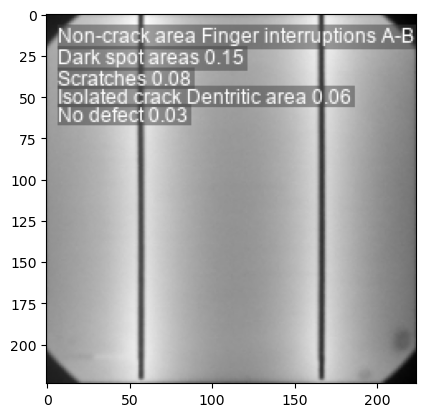

In [13]:
import cv2
import matplotlib.pyplot as plt
from PIL import Image

%matplotlib inline

#modelseg = YOLO("yolo11n-seg.pt")#denne virker
modelseg = YOLO("C:/SolarData/AnnotationData/runs/classify/train34/weights/best.pt")
# Predict with the model
results = modelseg("C:/SolarData/AnnotationData/DTUSinglecelldata/image_1_2.png")

# Visualize predictions
result_image = results[0].plot()
plt.imshow(result_image)
#plt.axis('off')
plt.show()

#print("result_image")
#print(result_image)

img = Image.fromarray(result_image, 'RGB')
#img.save('my.png')
img.show()

In [47]:
# Package imports and train path
import cv2
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

train_path = './runs/classify/train'


ModuleNotFoundError: No module named 'imp'

In [11]:
# Validation Results: Ground Truth vs Prediction

# Load your images using matplotlib's imread
img1 = mpimg.imread(f'{train_path}/val_batch0_labels.jpg')
img2 = mpimg.imread(f'{train_path}/val_batch0_pred.jpg')
img3 = mpimg.imread(f'{train_path}/val_batch1_labels.jpg')
img4 = mpimg.imread(f'{train_path}/val_batch1_pred.jpg')
img5 = mpimg.imread(f'{train_path}/val_batch2_labels.jpg')
img6 = mpimg.imread(f'{train_path}/val_batch2_pred.jpg')

# Get image dimensions (assuming all images are of the same size)
img_height, img_width, _ = img1.shape

# Create a figure with subplots, adjusting the figure size to match the image size
fig, axes = plt.subplots(6, 1, figsize=(img_width / 100, 6 * img_height / 100))  # 6 rows, 1 column

# Add a title to the figure with a bigger font size
# fig.suptitle('Validation Results: Ground Truth vs Prediction', fontsize=24)

# Plot the images and add larger titles for each subplot
axes[0].imshow(img1)
axes[0].set_title("Ground Truth - Batch 0", fontsize=22)  # Larger subplot title
axes[1].imshow(img2)
axes[1].set_title("Prediction - Batch 0", fontsize=22)

axes[2].imshow(img3)
axes[2].set_title("Ground Truth - Batch 1", fontsize=22)
axes[3].imshow(img4)
axes[3].set_title("Prediction - Batch 1", fontsize=22)

axes[4].imshow(img5)
axes[4].set_title("Ground Truth - Batch 2", fontsize=22)
axes[5].imshow(img6)
axes[5].set_title("Prediction - Batch 2", fontsize=22)

# Turn off axes for all subplots
for ax in axes:
    ax.axis('off')

# Adjust layout to prevent overlap and show the title
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Display the plot
plt.show()


NameError: name 'mpimg' is not defined

# This project is only for learning purpose
The accuracy of the model is very low because it has been trained over very few epochs.


image 1/1 C:\SolarData\AnnotationData\DTUSinglecelldata\image_1_2.png: 224x224 (no detections), 46.9ms
Speed: 0.7ms preprocess, 46.9ms inference, 0.2ms postprocess per image at shape (1, 3, 224, 224)


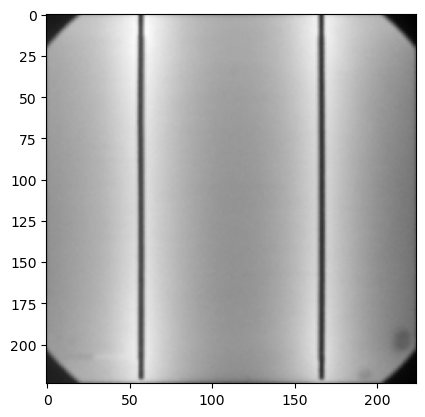

In [24]:
import cv2
import matplotlib.pyplot as plt
from PIL import Image

%matplotlib inline



#modelseg = YOLO("yolo11n-seg.pt")
# Predict with the model
imgresults = model("C:/SolarData/AnnotationData/DTUSinglecelldata/image_1_2.png")

# Visualize predictions
result_image = imgresults[0].plot()
plt.imshow(result_image)
#plt.axis('off')
plt.show()

#print("result_image")
#print(result_image)

img = Image.fromarray(result_image, 'RGB')
#img.save('my.png')
img.show()

In [25]:
model = YOLO("yolo11s-seg.pt")
print(model.train.__doc__) 


Train the model using the specified dataset and training configuration.

This method facilitates model training with a range of customizable settings. It supports training with a
custom trainer or the default training approach. The method handles scenarios such as resuming training
from a checkpoint, integrating with Ultralytics HUB, and updating model and configuration after training.

When using Ultralytics HUB, if the session has a loaded model, the method prioritizes HUB training
arguments and warns if local arguments are provided. It checks for pip updates and combines default
configurations, method-specific defaults, and user-provided arguments to configure the training process.

Args:
    trainer (BaseTrainer, optional): Custom trainer instance for model training. If None, uses default.
    **kwargs (Any): Arbitrary keyword arguments for training configuration. Common options include:
        data (str): Path to dataset configuration file.
        epochs (int): Number of traini

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11s-seg.pt")
model.train(
    task="segment",           # or "detect"/"classify"
    data="data.yaml",
    epochs=30,
    imgsz=640,
    batch=8,
    augment=True,             # <-- turn on augmentations
    project="runs/train",
    name="exp_with_augment",
    exist_ok=True
)